In [1]:
import fastf1
import pandas as pd
import numpy as np
import requests
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

In [2]:
# fastf1.Cache.enable_cache("f1_cache")

In [3]:
# 17 for baku
baku_gp_2024 = fastf1.get_session(2024, 17, "R")
baku_gp_2024.load()
baku_laps_2024 = baku_gp_2024.laps[[
    "Driver", "LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]].copy()
baku_laps_2024.dropna(inplace=True)

req         WARNING 	DEFAULT CACHE ENABLED! (24.0 KB) C:\Users\maitr\AppData\Local\Temp\fastf1
core           INFO 	Loading data for Azerbaijan Grand Prix - Race [v3.5.3]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for lap_count. Loading data...
_api           INFO 	Fetching lap count data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching tr

In [4]:
for num in baku_gp_2024.drivers:
    driver_info = baku_gp_2024.get_driver(num)
    print(f"{num} → {driver_info['Abbreviation']} ({driver_info['FullName']})")

81 → PIA (Oscar Piastri)
16 → LEC (Charles Leclerc)
63 → RUS (George Russell)
4 → NOR (Lando Norris)
1 → VER (Max Verstappen)
14 → ALO (Fernando Alonso)
23 → ALB (Alexander Albon)
43 → COL (Franco Colapinto)
44 → HAM (Lewis Hamilton)
50 → BEA (Oliver Bearman)
27 → HUL (Nico Hulkenberg)
10 → GAS (Pierre Gasly)
3 → RIC (Daniel Ricciardo)
24 → ZHO (Guanyu Zhou)
31 → OCO (Esteban Ocon)
77 → BOT (Valtteri Bottas)
11 → PER (Sergio Perez)
55 → SAI (Carlos Sainz)
18 → STR (Lance Stroll)
22 → TSU (Yuki Tsunoda)


In [5]:
# convert lap and sector times to seconds
for col in ["LapTime", "Sector1Time", "Sector2Time", "Sector3Time"]:
    baku_laps_2024[f"{col} (s)"] = baku_laps_2024[col].dt.total_seconds()

In [6]:
# aggregate sector times by driver
sector_times_2024 = baku_laps_2024.groupby("Driver").agg({
    "Sector1Time (s)": "mean",
    "Sector2Time (s)": "mean",
    "Sector3Time (s)": "mean"
}).reset_index()

sector_times_2024["TotalSectorTime (s)"] = (
    sector_times_2024["Sector1Time (s)"] +
    sector_times_2024["Sector2Time (s)"] +
    sector_times_2024["Sector3Time (s)"]
)

In [7]:
# clean-air-race-pace
laps = baku_gp_2024.laps
lap_clean = laps[(laps['IsAccurate']) & (
    laps['PitOutTime'].isna()) & (laps['PitInTime'].isna())]
clean_racep = lap_clean.groupby('Driver')['LapTime'].mean().dt.total_seconds()

print(clean_racep)

Driver
ALB    108.830652
ALO    108.817304
BEA    109.011804
BOT    110.094400
COL    109.041826
GAS    109.589562
HAM    108.854435
HUL    108.893130
LEC    108.023870
NOR    108.270391
OCO    110.448574
PER    108.022022
PIA    107.978851
RIC    109.909617
RUS    108.212174
SAI    107.992739
STR    109.466300
TSU    111.985900
VER    108.346289
ZHO    109.935109
Name: LapTime, dtype: float64


In [8]:
# change the qualifying data for baku 2025
baku_quali_2025 = pd.DataFrame({
    "Driver": ["VER", "SAI", "LAW", "ANT", "RUS", "TSU", "NOR", "HAD", "PIA", "LEC", "ALO", "HAM",
               "BOR", "STR", "BEA", "COL", "HUL", "GAS", "ALB", "OCO"],
    "QualifyingTime (s)": [
        101.117, #Ver
        101.595, #sai
        101.707, #law
        101.717, #ant
        102.070, #rus
        102.143, #tsu
        102.239,   #nor
        102.372,    #had
        None,   #pia
        None,   #lec
        101.719, #alo
        102.045,    #ham
        102.139,    #bor
        103.922,    #str
        None,       #bea
        102.574,    #col
        102.711,    #hul
        102.744,    #gas
        102.933,    #alb
        102.503     #oco

    ]
})

baku_quali_2025["Clean Race Pace(s)"] = baku_quali_2025["Driver"].map(
    clean_racep)

In [9]:
# weather data for baku
API_KEY = "e5a48145d238575368c6902a1fbe86d0"
weather_url = f"http://api.openweathermap.org/data/2.5/forecast?lat=40.4093&lon=49.8671&appid={API_KEY}&units=metric"
response = requests.get(weather_url)
weather_data = response.json()
forecast_t = "2025-09-21 15:00:00"  
forecast_d = next(
    (f for f in weather_data["list"] if f["dt_txt"] == forecast_t), None)

prob_rain = forecast_d["pop"] if forecast_d else 0
temperature = forecast_d["main"]["temp"] if forecast_d else 20

In [10]:
# adjust qualifying time based on weather conditions
if prob_rain >= 0.75:
    baku_quali_2025["QualifyingTime"] = baku_quali_2025[
        "QualifyingTime (s)"] * baku_quali_2025["WetPerformanceFactor"]
else:
    baku_quali_2025["QualifyingTime"] = baku_quali_2025["QualifyingTime (s)"]

In [11]:
# add constructor's data

construtors = {
    "McLaren": 617, "Mercedes": 260, "Red Bull": 239, "Williams": 86, "Ferrari": 280,
    "Haas": 44, "Aston Martin": 62, "Kick Sauber": 55, "Racing Bulls": 61, "Alpine": 20
}

max_points = max(construtors.values())
team_performance_score = {team: points /
                          max_points for team, points in construtors.items()}

In [12]:
driver_team = {
    "VER": "Red Bull", "NOR": "McLaren", "PIA": "McLaren", "LEC": "Ferrari", "RUS": "Mercedes",
    "HAM": "Ferrari", "GAS": "Alpine", "ALO": "Aston Martin", "TSU": "Red Bull", "ANT": 'Mercedes',
    "BEA": 'Haas', "COL": "Alpine", "SAI": "Williams", 'ALB': 'Williams', "HUL": "Kick Sauber",
    "BOR": "Kick Sauber", "OCO": "Haas", "STR": "Aston Martin", "HAD": "Racing Bulls", "LAW": "Racing Bulls"
}

baku_quali_2025["Team"] = baku_quali_2025["Driver"].map(driver_team)
baku_quali_2025["TeamPerformanceScore"] = baku_quali_2025["Team"].map(
    team_performance_score)

In [13]:
# average position change at Monaco (quali pos - finish pos); positive means losing positions
# +ve = lost positions, -ve = gained position
'''
Baku Grid 2024 and Finish Position
P1 > LEC > P2 +1
P2 > PIA > P1 -1
P3 > SAI > DNF None
P4 > PER > DNF None
P5 > RUS > P3 -2
P6 > VER > P5 -1
P7 > ALO > P6 +1
P8 > COL > P8 0
P9 > ALB > P7 -2
P10 > BEA > P10 0
P11 > TSU > DNF None
P12 > HUL > P11 -1
P13 > STR > DNF None
P14 > RIC > P13 -1
P15 > NOR > P4 -11
P16 > BOT > P16 None
P17 > ZHO > P14 -3
P18 > GAS > P12 -6
P19 > HAM > P9 -10
P20 > OCO > P15 -5

'''
position_change_baku = {
    "LEC": +1.0,   # P1→P2
    "PIA": -1.0,   # P2→P1
    "SAI": None,   # DNF
    "PER": None,   # DNF
    "RUS": -2.0,   # P5→P3
    "VER": -1.0,   # P6→P5
    "ALO": +1.0,   # P7→P6
    "COL":  0.0,   # P8→P8
    "ALB": -2.0,   # P9→P7
    "BEA":  0.0,   # P10→P10
    "TSU": None,   # DNF
    "HUL": -1.0,   # P12→P11
    "STR": None,   # DNF
    "RIC": -1.0,   # P14→P13
    "NOR": -11.0,  # P15→P4
    "BOT":  0.0,   # P16→P16
    "ZHO": -3.0,   # P17→P14
    "GAS": -6.0,   # P18→P12
    "HAM": -10.0,  # P19→P9
    "OCO": -5.0    # P20→P15
}
baku_quali_2025["Position Change 2024"] = baku_quali_2025["Driver"].map(
    position_change_baku)

In [14]:
# merge qualifying and sector times data
merged_data = baku_quali_2025.merge(
    sector_times_2024[["Driver", "TotalSectorTime (s)"]], on="Driver", how="left")
merged_data["Rain Probability"] = prob_rain
merged_data["Temperature"] = temperature
merged_data["QualifyingTime"] = merged_data["QualifyingTime"]

valid_drivers = merged_data["Driver"].isin(baku_laps_2024["Driver"].unique())
merged_data = merged_data[valid_drivers]

In [15]:
# define features (X) and target (y)
X = merged_data[[
    "QualifyingTime", "Rain Probability", "Temperature", "TeamPerformanceScore",
    "Clean Race Pace(s)", "Position Change 2024"
]]
y = baku_laps_2024.groupby(
    "Driver")["LapTime (s)"].mean().reindex(merged_data["Driver"])

In [16]:
# impute missing values for features
impute = SimpleImputer(strategy="median")
X_impute = impute.fit_transform(X)

# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_impute, y, test_size=0.3, random_state=37)

In [17]:
# train gradient boosting model
baku_model_1 = XGBRegressor(n_estimators=300,learning_rate=0.8,max_depth=3,random_state=39,monotone_constraints='(1,0,-2)')
baku_model_2=RandomForestRegressor(n_estimators=500,max_depth=5,random_state=42)
baku_model_3 = GradientBoostingRegressor(n_estimators=100, learning_rate=0.7, max_depth=3, random_state=37)
baku_model_1.fit(X_train, y_train)
baku_model_2.fit(X_train,y_train)
baku_model_3.fit(X_train,y_train)
merged_data["PredictedRaceTime (s) for XGBoost"] = baku_model_1.predict(X_impute)
merged_data["PredictedRaceTime (s) for RandomForestRegressor"] = baku_model_2.predict(X_impute)
merged_data["PredictedRaceTime (s) for GradientBoostingRegressor"] = baku_model_3.predict(X_impute)

y_pred_1 = baku_model_1.predict(X_test)
print(f"Model Error for XGBoost(MAE): {mean_absolute_error(y_test, y_pred_1):.2f} seconds")
y_pred_2 = baku_model_2.predict(X_test)
print(f"Model Error for RandomForestRegressor(MAE): {mean_absolute_error(y_test, y_pred_2):.2f} seconds")
y_pred_3 = baku_model_3.predict(X_test)
print(f"Model Error for GradientBoostingRegressor(MAE): {mean_absolute_error(y_test, y_pred_3):.2f} seconds")

Model Error for XGBoost(MAE): 0.96 seconds
Model Error for RandomForestRegressor(MAE): 0.41 seconds
Model Error for GradientBoostingRegressor(MAE): 0.55 seconds



🏁 2025 Azerbaijan GP Race Predictions 🏁

   Driver  PredictedRaceTime (s) for RandomForestRegressor
8     PIA                                       108.581154
9     LEC                                       108.700342
6     NOR                                       108.798594
0     VER                                       109.165791
4     RUS                                       109.196955
1     SAI                                       109.505417
11    HAM                                       109.581679
14    BEA                                       109.809490
10    ALO                                       109.979552
18    ALB                                       110.128714
16    HUL                                       110.150500
15    COL                                       110.150978
17    GAS                                       110.373853
19    OCO                                       110.488400
13    STR                                       110.512791
5     TSU     

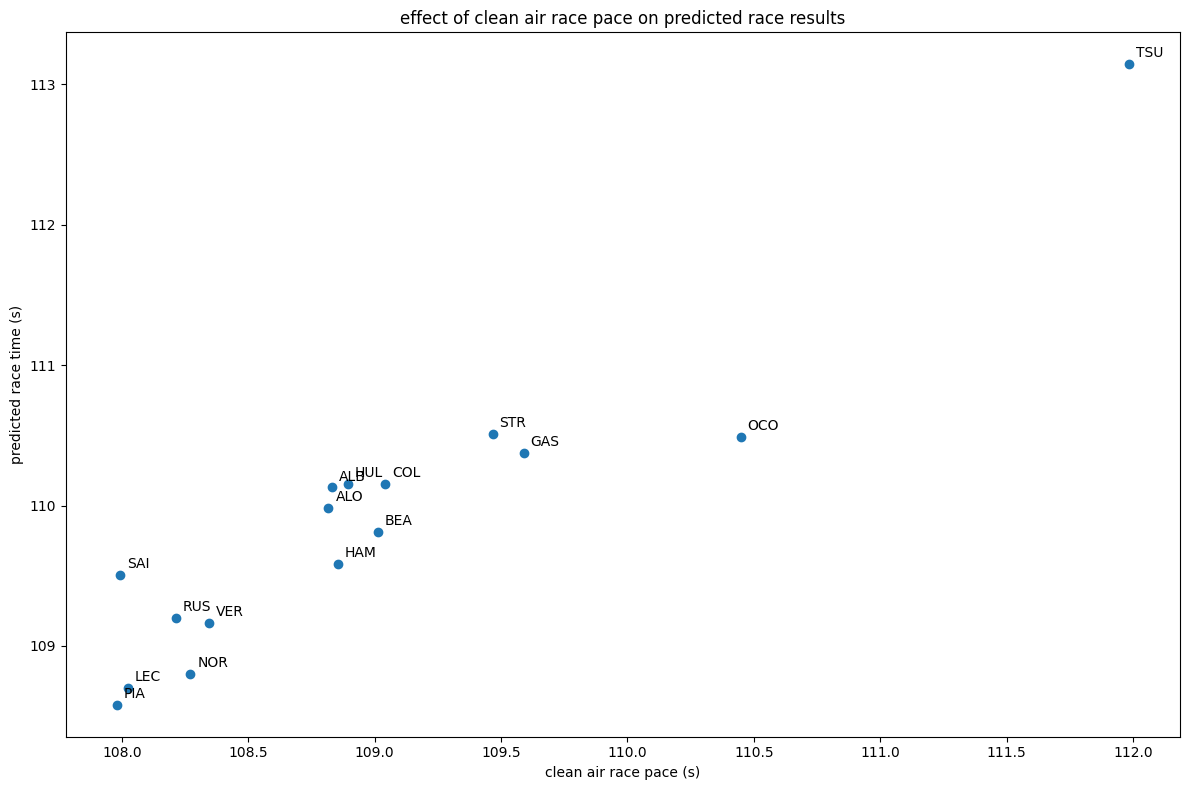

In [18]:
# sort the results to find the predicted winner
top_10 = merged_data.sort_values("PredictedRaceTime (s) for RandomForestRegressor")
print("\n🏁 2025 Azerbaijan GP Race Predictions 🏁\n")
print(top_10[["Driver", "PredictedRaceTime (s) for RandomForestRegressor"]])
y_pred = baku_model_2.predict(X_test)
print(f"Model Error (MAE): {mean_absolute_error(y_test, y_pred):.2f} seconds")

plt.figure(figsize=(12, 8))
plt.scatter(top_10["Clean Race Pace(s)"], top_10["PredictedRaceTime (s) for RandomForestRegressor"])
for i, driver in enumerate(top_10["Driver"]):
    plt.annotate(driver, (top_10["Clean Race Pace(s)"].iloc[i], top_10["PredictedRaceTime (s) for RandomForestRegressor"].iloc[i]),
                 xytext=(5, 5), textcoords='offset points')
plt.xlabel("clean air race pace (s)")
plt.ylabel("predicted race time (s)")
plt.title("effect of clean air race pace on predicted race results")
plt.tight_layout()
plt.show()


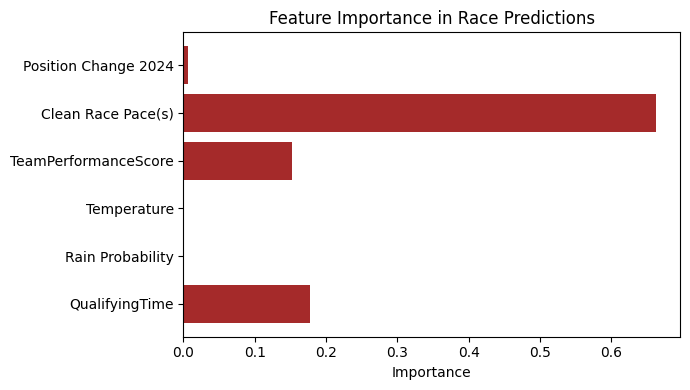

In [19]:
# Plot feature importances
feature_importance = baku_model_2.feature_importances_
features = X.columns

plt.figure(figsize=(7, 4))
plt.barh(features, feature_importance, color='brown')
plt.xlabel("Importance")
plt.title("Feature Importance in Race Predictions")
plt.tight_layout()
plt.show()


In [20]:
# sort results and get top 3
top_10 = merged_data.sort_values(
    "PredictedRaceTime (s) for RandomForestRegressor").reset_index(drop=True)
podium = top_10.loc[:2, ["Driver", "PredictedRaceTime (s) for RandomForestRegressor"]]

print("\n🏆 Predicted in the Top 3 🏆")
print(f"P1: {podium.iloc[0]['Driver']}")
print(f"P2: {podium.iloc[1]['Driver']}")
print(f"P3: {podium.iloc[2]['Driver']}")


🏆 Predicted in the Top 3 🏆
P1: PIA
P2: LEC
P3: NOR
